# ch196 — Iterative Methods for Linear Systems

> **Prerequisites:** ch160 (Systems of Linear Equations), ch192 (Rank/Nullity), ch194 (Condition Numbers), ch195 (Sparse Matrices)
> **You will learn:**
> - Why direct solvers fail at large scale
> - Jacobi, Gauss-Seidel, and Successive Over-Relaxation (SOR)
> - Conjugate Gradient and Krylov subspaces
> - Convergence analysis and preconditioning
> - When to use iterative vs. direct solvers
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Gaussian elimination *(ch161)* costs $O(n^3)$ operations and $O(n^2)$ storage — infeasible for $n > 10^5$. **Iterative methods** start with an initial guess and refine it using only matrix-vector products, costing $O(nnz)$ per iteration *(ch195)*.

The price: convergence is not guaranteed, and speed depends strongly on the condition number *(ch194)*. Well-chosen preconditioners can dramatically accelerate convergence.

Common misconception: iterative methods are approximate. In exact arithmetic, CG finds the exact solution in at most $n$ steps.

## 2. Intuition & Mental Models

**Jacobi:** update each component $x_i$ using values from the *previous* iteration — solve each equation independently, holding others fixed. Converges when the diagonal of $A$ dominates the off-diagonals.

**Gauss-Seidel:** use freshly updated values immediately. Each component sees more current information → faster convergence than Jacobi.

**Conjugate Gradient (CG):** optimal for symmetric positive definite (SPD) systems. At step $k$, the solution lies in the Krylov subspace $\mathcal{K}_k = \text{span}\{\mathbf{r}_0, A\mathbf{r}_0, \ldots, A^{k-1}\mathbf{r}_0\}$. CG minimizes the error over this subspace — it converges in at most $n$ steps, often far fewer.

## 3. Visualization

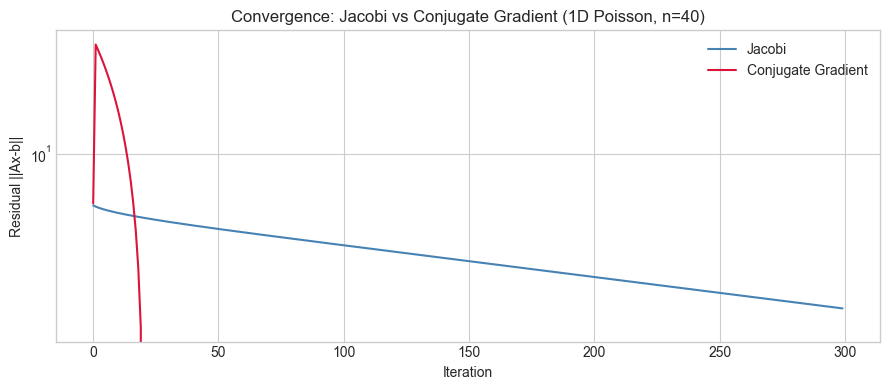

CG converges in O(sqrt(κ)) iterations; Jacobi in O(κ).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

def poisson_1d(n):
    """1D Poisson system: tridiagonal SPD matrix."""
    return 2*np.eye(n) - np.diag(np.ones(n-1),1) - np.diag(np.ones(n-1),-1)

def jacobi(A, b, n_iters=300):
    x = np.zeros(len(b))
    D_inv = 1.0 / np.diag(A)
    R = A - np.diag(np.diag(A))
    errs = []
    for _ in range(n_iters):
        x = D_inv * (b - R @ x)
        errs.append(np.linalg.norm(A @ x - b))
        if errs[-1] < 1e-12: break
    return x, errs

def conjugate_gradient(A, b, n_iters=None):
    n = len(b)
    if n_iters is None: n_iters = n
    x = np.zeros(n)
    r = b.copy()
    p = r.copy()
    errs = [np.linalg.norm(r)]
    for _ in range(n_iters):
        Ap = A @ p
        alpha = np.dot(r, r) / (np.dot(p, Ap) + 1e-300)
        x += alpha * p
        r_new = r - alpha * Ap
        beta = np.dot(r_new, r_new) / (np.dot(r, r) + 1e-300)
        p = r_new + beta * p
        r = r_new
        errs.append(np.linalg.norm(r))
        if errs[-1] < 1e-12: break
    return x, errs

N = 40
A_p = poisson_1d(N)
b_p = np.ones(N)

_, errs_j = jacobi(A_p, b_p)
_, errs_cg = conjugate_gradient(A_p, b_p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(errs_j,  color='steelblue',  label='Jacobi')
ax.semilogy(errs_cg, color='crimson',    label='Conjugate Gradient')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual ||Ax-b||')
ax.set_title('Convergence: Jacobi vs Conjugate Gradient (1D Poisson, n=40)')
ax.legend()
plt.tight_layout()
plt.show()
print('CG converges in O(sqrt(κ)) iterations; Jacobi in O(κ).')

## 4. Mathematical Formulation

**Jacobi:** split $A = D + R$:
$$\mathbf{x}^{(k+1)} = D^{-1}(\mathbf{b} - R\mathbf{x}^{(k)})$$
Converges iff spectral radius $\rho(D^{-1}R) < 1$.

**CG iteration:** search directions are $A$-conjugate ($\mathbf{p}_i^\top A \mathbf{p}_j = 0$ for $i \neq j$):
$$\alpha_k = \frac{\mathbf{r}_k^\top \mathbf{r}_k}{\mathbf{p}_k^\top A \mathbf{p}_k}, \quad \mathbf{x}_{k+1} = \mathbf{x}_k + \alpha_k \mathbf{p}_k$$

**Convergence bound for CG:**
$$\frac{\|\mathbf{e}_k\|_A}{\|\mathbf{e}_0\|_A} \leq 2\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k$$
Lower $\kappa$ = faster convergence *(ch194)*.

## 5. Python Implementation

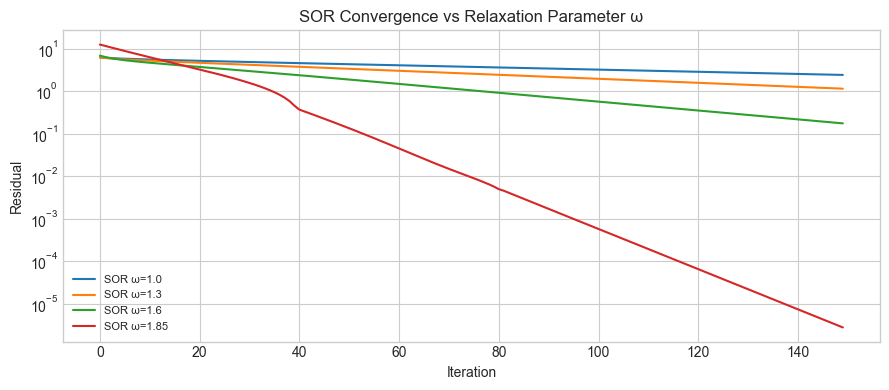

Optimal ω ≈ 1.6–1.9 for this system. Too large → diverges.


In [2]:
def gauss_seidel(A, b, n_iters=200, omega=1.0):
    """
    Gauss-Seidel (omega=1) or SOR (omega != 1).
    omega > 1: over-relaxation (typically faster, optimal 1 < omega < 2)
    """
    n = len(b)
    x = np.zeros(n)
    errs = []
    for _ in range(n_iters):
        for i in range(n):
            s = b[i] - sum(A[i,j]*x[j] for j in range(n) if j != i)
            x_gs = s / A[i, i]
            x[i] = (1 - omega) * x[i] + omega * x_gs
        errs.append(np.linalg.norm(A @ x - b))
        if errs[-1] < 1e-12: break
    return x, errs

fig, ax = plt.subplots(figsize=(9, 4))
for omega in [1.0, 1.3, 1.6, 1.85]:
    _, errs = gauss_seidel(A_p, b_p, n_iters=150, omega=omega)
    ax.semilogy(errs, label=f'SOR ω={omega}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual')
ax.set_title('SOR Convergence vs Relaxation Parameter ω')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print('Optimal ω ≈ 1.6–1.9 for this system. Too large → diverges.')

## 6. Experiments

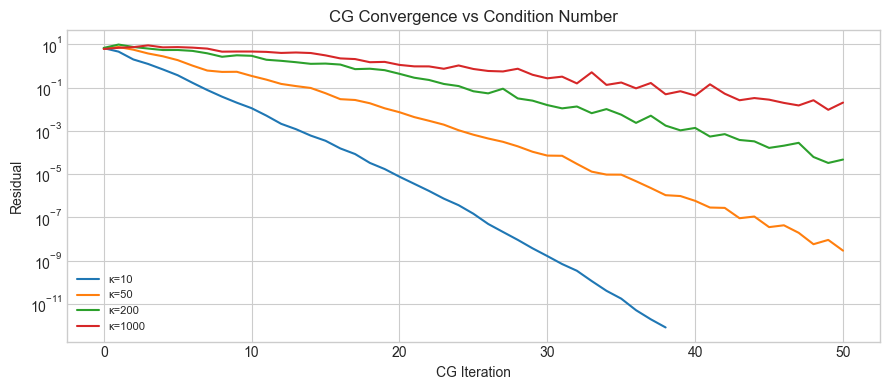

In [3]:
# --- Experiment: CG convergence vs condition number ---
# Hypothesis: higher κ(A) → more CG iterations to reach tolerance.
# Try changing: KAPPA_LIST, N_EXP

KAPPA_LIST = [10, 50, 200, 1000]   # <-- modify
N_EXP = 50

fig, ax = plt.subplots(figsize=(9, 4))
for kappa in KAPPA_LIST:
    U_e, _ = np.linalg.qr(rng.normal(0,1,(N_EXP, N_EXP)))
    s_e = np.geomspace(kappa, 1, N_EXP)
    A_e = U_e @ np.diag(s_e) @ U_e.T
    b_e = rng.normal(0,1,N_EXP)
    _, errs = conjugate_gradient(A_e, b_e, n_iters=N_EXP)
    ax.semilogy(errs, label=f'κ={kappa}')
ax.set_xlabel('CG Iteration')
ax.set_ylabel('Residual')
ax.set_title('CG Convergence vs Condition Number')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** Show that Jacobi for a diagonal $A$ converges in exactly 1 iteration. What is $D^{-1}R$ in this case?

**Easy 2.** Implement the residual stopping criterion: stop when `||Ax-b||/||b|| < tol`. Count how many Jacobi iterations reach `tol=1e-6` for the Poisson system of size $n=50$.

**Medium 1.** Find a $2\times2$ SPD matrix for which Jacobi diverges but Gauss-Seidel converges. Hint: look at the spectral radius condition $\rho(D^{-1}R) < 1$.

**Medium 2.** Implement **preconditioned CG** using the Jacobi (diagonal) preconditioner: replace $A\mathbf{x}=\mathbf{b}$ with $M^{-1}A\mathbf{x}=M^{-1}\mathbf{b}$ where $M=\text{diag}(A)$. Compare to unpreconditioned CG on an ill-conditioned system.

**Hard.** Implement **GMRES** (Generalized Minimum Residual) for non-symmetric systems: build an orthonormal Krylov basis using modified Gram-Schmidt, solve a small least-squares problem at each step. Apply to a non-symmetric sparse system of size $n=100$.

## 8. Mini Project

Grid: 15x15=225 unknowns
Direct: 64.8ms, CG (34 iters): 3.2ms
Error: 7.41e-14


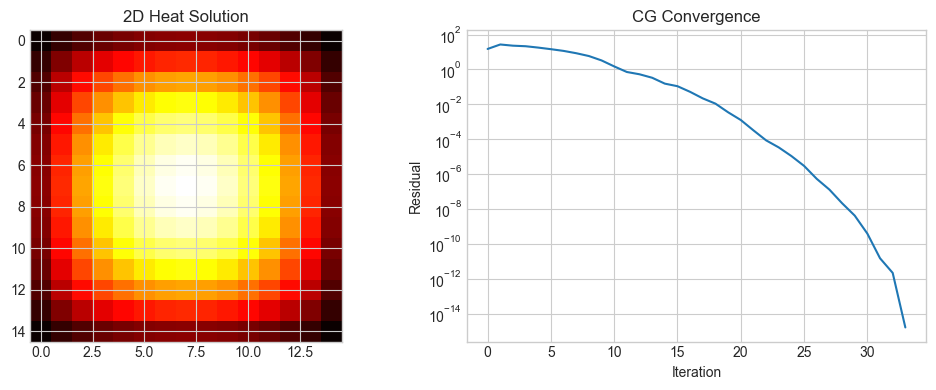

In [4]:
# --- Mini Project: Solve 2D Heat Equation with CG ---
import time

def laplacian_2d(n):
    N2 = n*n
    A = np.zeros((N2, N2))
    for i in range(n):
        for j in range(n):
            idx = i*n + j
            A[idx, idx] = 4.0
            if i > 0:   A[idx,(i-1)*n+j] = -1.0
            if i < n-1: A[idx,(i+1)*n+j] = -1.0
            if j > 0:   A[idx,i*n+(j-1)] = -1.0
            if j < n-1: A[idx,i*n+(j+1)] = -1.0
    return A

n_grid = 15
A_2d = laplacian_2d(n_grid)
b_2d = np.ones(n_grid**2)

t0 = time.perf_counter()
x_dir = np.linalg.solve(A_2d, b_2d)
t_dir = time.perf_counter() - t0

t0 = time.perf_counter()
x_cg, errs2d = conjugate_gradient(A_2d, b_2d)
t_cg2 = time.perf_counter() - t0

print(f'Grid: {n_grid}x{n_grid}={n_grid**2} unknowns')
print(f'Direct: {t_dir*1000:.1f}ms, CG ({len(errs2d)} iters): {t_cg2*1000:.1f}ms')
print(f'Error: {np.linalg.norm(x_cg - x_dir):.2e}')

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].imshow(x_dir.reshape(n_grid,n_grid), cmap='hot')
axes[0].set_title('2D Heat Solution')
axes[1].semilogy(errs2d)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Residual')
axes[1].set_title('CG Convergence')
plt.tight_layout()
plt.show()

## 9. Chapter Summary & Connections

- Iterative methods solve $A\mathbf{x}=\mathbf{b}$ via repeated matrix-vector products at $O(nnz)$ per step — scalable to millions of unknowns *(ch195)*.
- Jacobi and Gauss-Seidel converge when $A$ is diagonally dominant; CG is optimal for SPD systems and converges in $O(\sqrt{\kappa})$ iterations.
- The condition number *(ch194)* governs convergence rate; preconditioning reduces effective $\kappa$.
- CG is the algorithmic complement to gradient descent for quadratic objectives: they are the same algorithm on the quadratic loss $\frac{1}{2}\mathbf{x}^\top A \mathbf{x} - \mathbf{b}^\top \mathbf{x}$.

**Forward:** CG's connection to gradient descent on quadratics is made explicit in ch212 (Gradient Descent), where the convergence rate $\left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^k$ appears again. Preconditioning connects to ch273 (Regression) and the normal equations.

**Backward:** Iterative methods complement ch161 (Gaussian Elimination) and ch163 (LU Decomposition). The Krylov subspace framework connects back to ch171 (Eigenvalue Computation) via the power method.